## 6 - Pie & Donut Charts

### What is a Pie Chart?
A **pie chart** shows each category as a **slice of a circle**. The size of each slice represents that category's proportion of the whole (always adds up to 100%).

### When to use a Pie Chart
✅ Showing part-to-whole relationships
✅ When there are 5 or fewer categories
✅ When the differences between slices are large and obvious
❌ Too many categories (>6) → use horizontal bar chart instead
❌ When values are very similar → hard to see the difference
❌ For trends over time → use line chart

### Key `plt.pie()` parameters
| Parameter | What it does |
|-----------|-------------|
| `x` | Values (auto-normalised to 100%) |
| `labels` | Category names |
| `autopct` | Show % on slice — `'%1.1f%%'` |
| `explode` | Pull a slice out — e.g. `[0, 0.1, 0, 0]` |
| `startangle` | Rotate starting point (90 = top) |
| `shadow` | Add drop shadow |
| `colors` | Custom color list |
| `wedgeprops` | Dict for slice styling |

### Donut Chart
A donut is a pie with `wedgeprops=dict(width=0.5)` - setting the width less than 1 creates the hole:
```python
plt.pie(values, wedgeprops=dict(width=0.5))   # width < 1 = donut hole
```
You can then add text in the centre using `plt.text(0, 0, 'label')`.


In [1]:
import matplotlib.pyplot as plt

In [2]:
grade_labels  = ['A', 'B', 'C', 'D', 'F']
grade_counts  = [12, 18, 11, 6, 3]
grade_colors  = ['#55A868', '#4C72B0', '#DD8452', '#8172B3', '#C44E52']

city_labels   = ['Delhi', 'Mumbai', 'Pune', 'Bangalore', 'Hyderabad']
city_counts   = [14, 11, 9, 10, 6]
city_colors   = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']

### Plot 1 : Basic pie chart

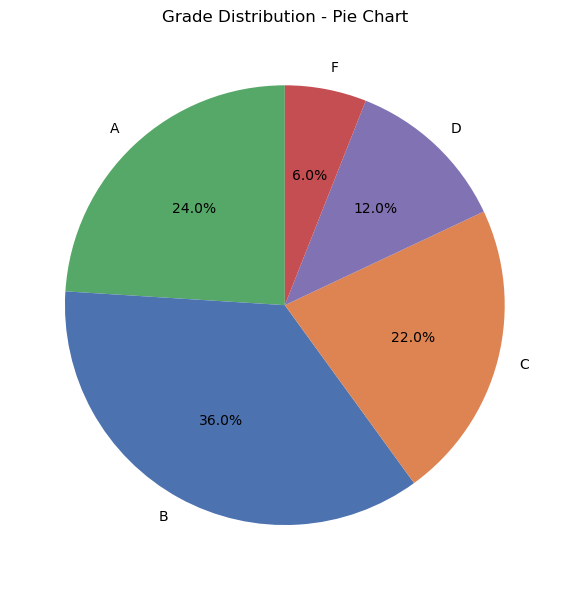

In [6]:
plt.figure(figsize=(8, 6))
plt.pie(grade_counts,
        labels=grade_labels,
        autopct='%1.1f%%',
        colors=grade_colors,
        startangle=90)

plt.title('Grade Distribution - Pie Chart',)

plt.tight_layout()
plt.show()

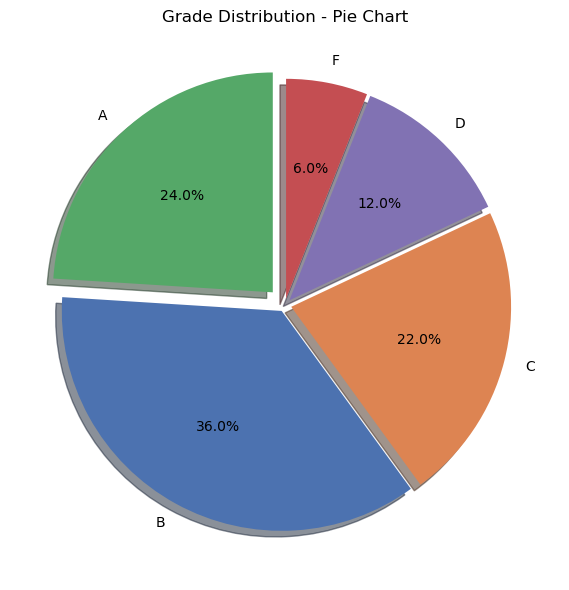

In [7]:
explode = [0.08, 0.03, 0.03, 0.03, 0.03]

plt.figure(figsize=(8, 6))
plt.pie(grade_counts,
        labels=grade_labels,
        autopct='%1.1f%%',
        explode=explode,
        colors=grade_colors,
        startangle=90,
        shadow=True)

plt.title('Grade Distribution - Pie Chart')

plt.tight_layout()
plt.show()

### Plot 2 : Donut chart 

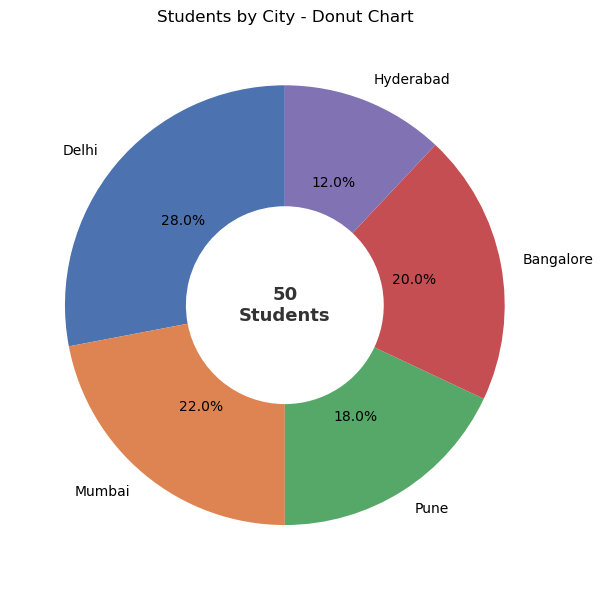

In [8]:
plt.figure(figsize=(8, 6))
plt.pie(city_counts,
        labels=city_labels,
        autopct='%1.1f%%',
        colors=city_colors,
        startangle=90,
        wedgeprops=dict(width=0.55))    # width < 1 creates donut hole

plt.text(0, 0, '50\nStudents', ha='center', va='center',
         fontsize=13, fontweight='bold', color='#333333')

plt.title('Students by City - Donut Chart')

plt.tight_layout()
plt.show()

### Plot 3 : Pie vs Bar comparison

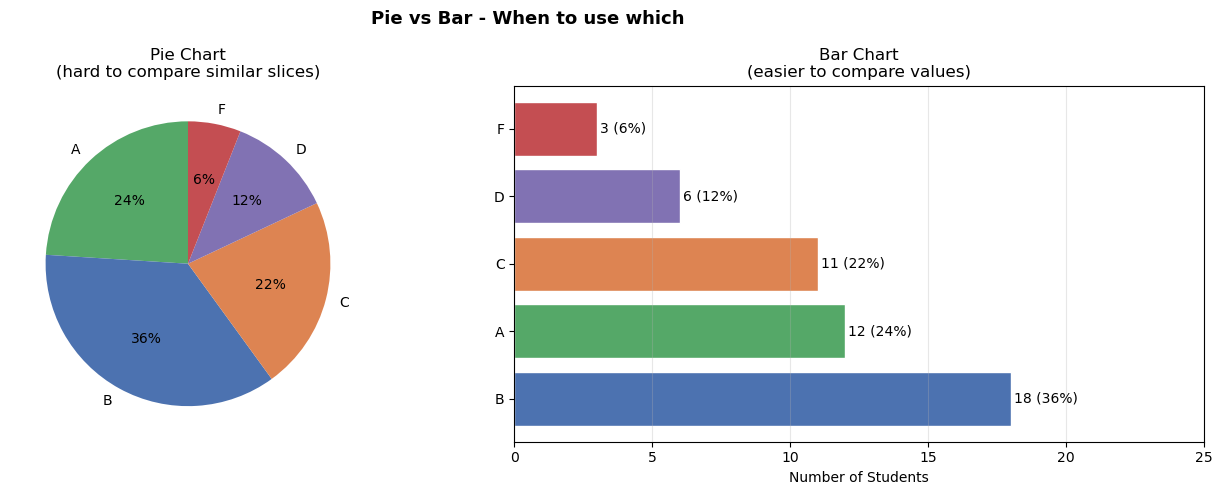

In [11]:
plt.figure(figsize=(14, 5))

# pir chart
plt.subplot(1, 2, 1)
plt.pie(grade_counts, labels=grade_labels, autopct='%1.0f%%',
        colors=grade_colors, startangle=90)
plt.title('Pie Chart\n(hard to compare similar slices)')

# BAr chart
plt.subplot(1, 2, 2)
sorted_idx = sorted(range(len(grade_counts)), key=lambda i: grade_counts[i], reverse=True)
sorted_labels = [grade_labels[i] for i in sorted_idx]
sorted_counts = [grade_counts[i] for i in sorted_idx]
sorted_colors = [grade_colors[i] for i in sorted_idx]
bars = plt.barh(sorted_labels, sorted_counts, color=sorted_colors, edgecolor='white')
for i, val in enumerate(sorted_counts):
    total = sum(grade_counts)
    plt.text(val + 0.1, i, f'{val} ({val/total*100:.0f}%)', va='center', fontsize=10)
plt.title('Bar Chart\n(easier to compare values)')
plt.xlabel('Number of Students')
plt.xlim(0, 25)
plt.grid(axis='x', alpha=0.3)

plt.suptitle('Pie vs Bar - When to use which', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()